In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bacco
import biparallel

In [2]:
basedir = '/home/mzennaro/CosmoCodes/Simulations/N768_L256/nenya_N768_output/0.00/'
halo_file = 'groups_081/fof_subhalo_history_tab_orph_wweight_081'
sim = bacco.Simulation(basedir=basedir, halo_file=halo_file)
sim

2026-06-09 16:14:02,045 bacco.sims : Initialising simulation Default
2026-06-09 16:14:02,047 bacco.sims : Loading /home/mzennaro/CosmoCodes/Simulations/N768_L256/nenya_N768_output/0.00/groups_081/fof_subhalo_history_tab_orph_wweight_081
2026-06-09 16:14:02,050 bacco.cosmo : Initialising 'Default' cosmology at z=0.00


Simulation(tag='Default', cosmo='Default', box=256.0, a=0.9990212338420196, z=0.001, N=452984832, format='gadget_hdf5', seed=-406168)

In [13]:
ngrid = 64
density_mesh = bacco.statistics.compute_mesh(ngrid=ngrid, box=sim.header['BoxSize'], pos=sim.sdm['pos'], vel=None,
                                             interlacing=True, deposit_method='tsc', folds=1, compensated=True,
                                             zspace=False, cosmology=sim.Cosmology, nthreads=None, twod=False)
density_mesh /= np.mean(density_mesh)
density_mesh -= 1

2026-06-09 16:15:31,121 bacco.statistics : Computing tsc mesh with 7077888 objects, ngrid=64, interlacing=True, and nthreads=14
bacco.fftw_utils: no FFTW wisdom for ngrid=64 nthreads=14 (out-of-place); building plans with FFTW_MEASURE (can take minutes for large grids; result will be saved to the wisdom file)...
bacco.fftw_utils: FFTW_MEASURE planning for ngrid=64 (out-of-place) done in 0.4 s (wisdom saved)


In [27]:
kmin = 2 * np.pi / sim.header['BoxSize']
kmax = np.pi * ngrid / sim.header['BoxSize'] / 2

dlogk = 0.1
kbins_log = np.arange(np.log10(kmin), np.log10(kmax), dlogk)
kbins_edges = 10**kbins_log

print(kbins_edges)
print(kbins_edges.shape)

[0.02454369 0.03089868 0.03889913 0.0489711  0.06165097 0.07761397
 0.0977102  0.12300985 0.15486023 0.19495748 0.24543693 0.30898678
 0.38899131]
(13,)


In [28]:
bp = biparallel.BiParallel(density_mesh, sim.header['BoxSize'])
bp.print_mesh()

density_mesh ndim=3 shape=(64, 64, 64)


In [29]:
raw_bisp = bp.compute_raw_bispectrum(kbins_edges)

density_mesh ndim=3 shape=(64, 64, 64)


In [30]:
norm_bisp = bp.compute_normalization(kbins_edges)

In [31]:
from bisputils import BaccoBispectrum
bb = BaccoBispectrum(sim)
big_res = bb.compute_bispectrum_BiG(ngrid=ngrid, kmin=kmin, kmax=kmax, dk=dlogk, binning_mode='log', compensated=True)

2026-06-09 16:20:26,833 bacco.statistics : Computing tsc mesh with 7077888 objects, ngrid=64, interlacing=True, and nthreads=14


[CudaDevice(id=0)]
N bins: 12
kbins: [0.02454369 0.03089868 0.03889913 0.0489711  0.06165097 0.07761397
 0.0977102  0.12300985 0.15486023 0.19495748 0.24543693 0.30898678
 0.38899131]
Finished setting members of bispectrumExtractor
Creating k-mesh
Doing Fourier Transformation of density field
Doing Bispec calculation
Doing Powerspec normalization calculation
Doing Fourier Transformation of density field
Doing Powerspec calculation


/home/mzennaro/CosmoCodes/biparallel/bisputils.py:59: RuntimeWarning: divide by zero encountered in divide
  eff_triangles = np.array(Xtract.calculateEffectiveTriangle_slow(mode=mode)).T / norm
/home/mzennaro/CosmoCodes/biparallel/bisputils.py:59: RuntimeWarning: invalid value encountered in divide
  eff_triangles = np.array(Xtract.calculateEffectiveTriangle_slow(mode=mode)).T / norm
/home/mzennaro/CosmoCodes/biparallel/bisputils.py:60: RuntimeWarning: invalid value encountered in divide
  bkkk = np.array(Xtract.calculateBispectrum_slow(density_grid, mode=mode, filetype=filetype)) / norm * prefactor


(165,)
(165,)


/tmp/ipykernel_94687/2376059269.py:4: RuntimeWarning: invalid value encountered in divide
  ax.semilogy(trindex, raw_bisp / norm_bisp / ngrid**9 * sim.header['BoxSize']**6, label='my bispectrum')


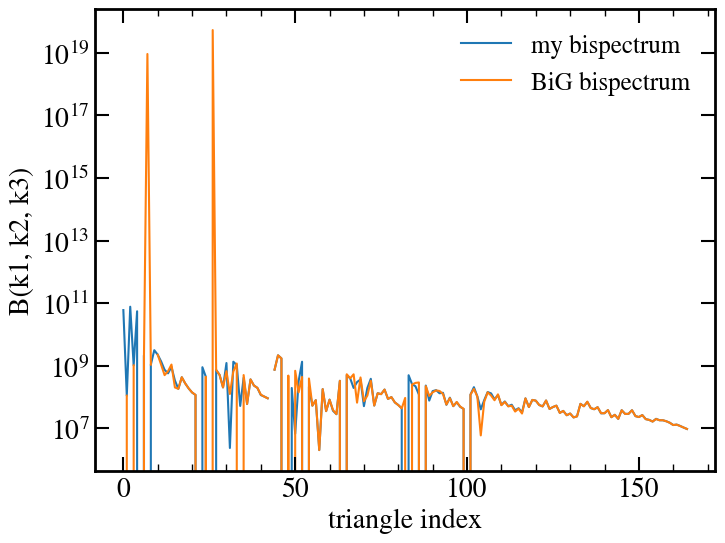

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

trindex = np.arange(len(raw_bisp))
ax.semilogy(trindex, raw_bisp / norm_bisp / ngrid**9 * sim.header['BoxSize']**6, label='my bispectrum')
ax.semilogy(trindex, big_res['bispectrum'], label='BiG bispectrum')
ax.set_xlabel('triangle index')
ax.set_ylabel('B(k1, k2, k3)')
ax.legend()

print(big_res['bispectrum'].shape)
print(raw_bisp.shape)

plt.show()